In [17]:
from src.original.OG_MO_AUMC_ICR_RMH_NL_UK.ExtendedTofts.DCE \
    import \
    fit_tofts_model, Cosine8AIF_ExtKety, fit_aif
from main import generate_dictionary, dictionary_matching, dictionary_fais
import matplotlib.pyplot as plt
import numpy as np
from joblib import Parallel, delayed
from itertools import product
import faiss
import joblib
print(joblib.cpu_count())



8


In [18]:
Kep = 0.5
dt = 5
ve = 0.1
vp = 0.03
noise = 0.02
example_AIF = [0.2307,0.1046,0.0173,0.0186,0.0141,0.0219,0.0144,0.0156,0.0199,0.0188,0.0252,0.0239,0.0227,0.0268,0.0344,0.0509,0.1001,0.3174,1.0889,2.5769,3.6526,4.9005,3.8691,3.4104,2.6086,1.9631,1.5876,1.2970,1.1123,1.0621,1.0603,1.1509,1.2014,1.2242,1.2162,1.2198,1.1582,1.0849,1.0513,1.0136,0.9672,0.9413,0.9075,0.9062,0.8725,0.8866,0.8663,0.8687,0.8663,0.8620,0.8623,0.8536,0.8729,0.8477,0.8334,0.8569,0.8100,0.8169,0.8166,0.8255,0.7980,0.8316,0.7979,0.7882,0.8072,0.7946,0.7805,0.7867,0.7818,0.7760,0.7725,0.7667,0.7608,0.7719,0.7447,0.7336,0.7409,0.7353,0.7310,0.7352,0.7079,0.7298,0.7124,0.7083,0.6959,0.6913,0.6953,0.6910,0.6817,0.6792,0.6929,0.6839,0.6727,0.6690,0.6637,0.6464,0.6631,0.6659,0.6516,0.6452,0.6736,0.6430,0.6580,0.6499,0.6457,0.6512,0.6290,0.6303,0.6287,0.6363,0.6161,0.6432,0.6260,0.6122,0.6208,0.6144,0.6150,0.6082,0.6174,0.5980,0.5975,0.6087,0.5959,0.6070,0.5976,0.5853,0.5958,0.5874,0.5800,0.5801,0.5812,0.5744,0.5808,0.5760,0.5768,0.5696,0.5709,0.5624,0.5629,0.5686,0.5885,0.5637,0.5690,0.5592,0.5406,0.5556,0.5552,0.5460,0.5563,0.5388,0.5450,0.5541,0.5544,0.5462, 0.5174, 0.5235, 0.4792, 0.4436, 0.4133, 0.3555]
timing = np.array(range(0, len(example_AIF)))/60*7.2e-3

model = 'Cosine8'
AIF = fit_aif(example_AIF, timing, model=model)
time_points = np.array(range(0, 60))*5/60
Hct=0.4
AIF['ab']=AIF['ab']/ (1. - Hct)
rg = np.random.RandomState(42)


Ctorig = Cosine8AIF_ExtKety(time_points, AIF, Kep, dt/60, ve, vp)
Ct = Ctorig + rg.normal(0, noise, len(Ctorig))



In [19]:
# Example usage:
alpha = 0.8
sets=1-np.linspace(0, 1, 50)**alpha
Kep_range = sets*1
alpha = 0.7
sets=1-np.linspace(0, 1,50)**alpha
ve_range = sets*0.3
vp_range = sets*0.1
dt_range = np.linspace(0, 15, 30)

dictionary = generate_dictionary(time_points, AIF, Kep_range, ve_range, vp_range,dt_range)



In [27]:
# Example usage:
best_params_dict, curve = dictionary_matching(Ct, dictionary)

paramsf = fit_tofts_model(Ct, time_points, AIF, model='Cosine8',X0=(5, 2, 1, 1))
params_zoom = fit_tofts_model(Ct, time_points, AIF, model='Cosine8',X0 = (best_params_dict[0], best_params_dict[3]/60, best_params_dict[1], best_params_dict[2]))


fitting 1 voxels
fitting 1 voxels


In [28]:
print(Kep, ve, vp, dt)
print(best_params_dict[0], best_params_dict[1], best_params_dict[2], best_params_dict[3])
print(paramsf[0],paramsf[2],paramsf[3],paramsf[1]*60)
print(params_zoom[0],params_zoom[2],params_zoom[3],params_zoom[1]*60)

0.5 0.1 0.03 5
0.4539588095757089 0.10233096885974464 0.029067115270716915 4.655172413793104
1.2730541283826207 0.07288980980413959 0.020983287307406805 119.01542030459062
0.43807357504438504 0.10268173446307624 0.03028390952057603 4.911049200795157


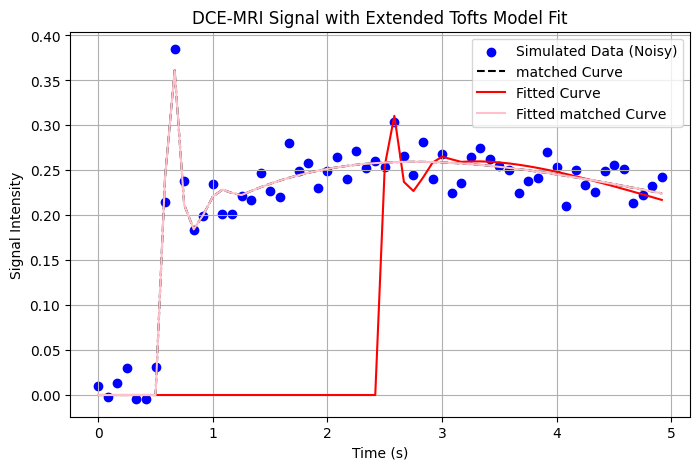

In [29]:
# Plot results
plt.figure(figsize=(8, 5))
plt.scatter(time_points, Ct, label="Simulated Data (Noisy)", color="blue")
plt.plot(time_points, curve, label="matched Curve", linestyle="dashed", color="black")
plt.plot(time_points, Cosine8AIF_ExtKety(time_points, AIF, paramsf[0], paramsf[1], paramsf[2], paramsf[3]), label="Fitted Curve", linestyle="solid", color="red")
plt.plot(time_points, Cosine8AIF_ExtKety(time_points, AIF, best_params_dict[0], best_params_dict[3]/60, best_params_dict[1], best_params_dict[2]), label="Fitted matched Curve", linestyle="solid", color="pink")

plt.xlabel("Time (s)")
plt.ylabel("Signal Intensity")
plt.title("DCE-MRI Signal with Extended Tofts Model Fit")
plt.legend()
plt.grid()
plt.show()

In [34]:
print(ve_range)
print(vp_range)
print(dt_range)

[0.3        0.28032186 0.26803277 0.25754109 0.24806908 0.23928961
 0.23102529 0.22316614 0.21563798 0.20838771 0.20137569 0.19457129
 0.18795026 0.18149291 0.17518303 0.16900706 0.16295349 0.15701244
 0.15117539 0.14543487 0.13978433 0.13421795 0.12873056 0.12331752
 0.11797465 0.11269818 0.10748466 0.10233097 0.09723424 0.09219184
 0.08720135 0.08226052 0.07736728 0.07251972 0.06771603 0.06295455
 0.05823371 0.05355205 0.04890821 0.04430089 0.03972887 0.03519103
 0.03068627 0.02621357 0.02177198 0.01736056 0.01297847 0.00862486
 0.00429895 0.        ]
[0.1        0.09344062 0.08934426 0.08584703 0.08268969 0.0797632
 0.07700843 0.07438871 0.07187933 0.06946257 0.06712523 0.0648571
 0.06265009 0.06049764 0.05839434 0.05633569 0.05431783 0.05233748
 0.0503918  0.04847829 0.04659478 0.04473932 0.04291019 0.04110584
 0.03932488 0.03756606 0.03582822 0.03411032 0.03241141 0.03073061
 0.02906712 0.02742017 0.02578909 0.02417324 0.02257201 0.02098485
 0.01941124 0.01785068 0.01630274 0.0147

In [35]:

sims=20
vp_min=0
vp_max=0.1
ve_min=0
ve_max=0.3
kep_min=0.1
kep_max=1
Tonset_min=0
Tonset_max=20
rg = np.random.RandomState(42)
test = rg.uniform(0, 1, (sims, 1))
vp = vp_min+ (test * (vp_max- vp_min))
test = rg.uniform(0, 1, (sims, 1))
ve = ve_min + (test * (ve_max - ve_min))
test = rg.uniform(0, 1, (sims, 1))
Kep = kep_min + (test * (kep_max - kep_min))
dt = rg.uniform(Tonset_min, Tonset_max, (sims, 1))
Ct = np.zeros((sims, len(time_points)))
error_matrix = np.zeros((3, len(Kep), 4))  # [2 models, num_samples, 3 parameters]

for aa in range(len(Kep)):
    Ctorig = Cosine8AIF_ExtKety(time_points, AIF, Kep[aa], dt[aa]/60, ve[aa], vp[aa])
    Ct = Ctorig + rg.normal(0, noise, len(Ctorig))
    best_params_dict, curve = dictionary_matching(Ct, dictionary)
    paramsf = fit_tofts_model(Ct, time_points, AIF, model='Cosine8',X0=(0.6, 0.3, 0.03, 0.0025)) #X0=(0.6, 0, 0.03, 0.0025)
    params_zoom = fit_tofts_model(Ct, time_points, AIF, model='Cosine8',X0 = (best_params_dict[0], best_params_dict[3]/60, best_params_dict[1], best_params_dict[2]))

    fitted_params0 = np.array([best_params_dict[0], best_params_dict[3], best_params_dict[1],best_params_dict[2]])
    fitted_params1 = np.array([paramsf[0], paramsf[1] * 60, paramsf[2],paramsf[3]])  #
      # Convert dt from minutes to seconds
    fitted_params2 = np.array([params_zoom[0], params_zoom[1] * 60, params_zoom[2],params_zoom[3]])  #
      # Convert dt from minutes to seconds

    true_params = np.array([Kep[aa], dt[aa], ve[aa], vp[aa]])  # Ground-truth values (including dt)
    # Ground-truth values

    error_matrix[0, aa, :] = fitted_params0 - true_params.flatten()  # Error for params_zoom
    error_matrix[1, aa, :] = fitted_params1 - true_params.flatten() # Error for
    error_matrix[2, aa, :] = fitted_params2 - true_params.flatten()  # Error for params_zoom


fitting 1 voxels
fitting 1 voxels
fitting 1 voxels
fitting 1 voxels
fitting 1 voxels
fitting 1 voxels
fitting 1 voxels
fitting 1 voxels
fitting 1 voxels
fitting 1 voxels
fitting 1 voxels
fitting 1 voxels
fitting 1 voxels
fitting 1 voxels
fitting 1 voxels
fitting 1 voxels
fitting 1 voxels
fitting 1 voxels
fitting 1 voxels
fitting 1 voxels
fitting 1 voxels
fitting 1 voxels
fitting 1 voxels
fitting 1 voxels
fitting 1 voxels
fitting 1 voxels
fitting 1 voxels
fitting 1 voxels
fitting 1 voxels
fitting 1 voxels
fitting 1 voxels
fitting 1 voxels
fitting 1 voxels
fitting 1 voxels
fitting 1 voxels
fitting 1 voxels
fitting 1 voxels
fitting 1 voxels
fitting 1 voxels
fitting 1 voxels


In [36]:
# Compute average errors across all samples
average_errors = np.mean(np.abs(error_matrix), axis=1)  # Shape: (2,4) → (paramsf errors, params_zoom errors)

# Print average fit errors
print("Average Fit Errors (dict): Kep={}, ve={}, vp={}, dt={}".format(*average_errors[0]))
print("Average Fit Errors (paramsf): Kep={}, ve={}, vp={}, dt={}".format(*average_errors[1]))
print("Average Fit Errors (params_zoom): Kep={}, ve={}, vp={}, dt={}".format(*average_errors[2]))


Average Fit Errors (dict): Kep=0.09270396709364141, ve=0.6989219966409178, vp=0.010577176763263642, dt=0.00314571293795318
Average Fit Errors (paramsf): Kep=0.22321369524901233, ve=6.0722840863434815, vp=0.017316553263649587, dt=0.013660333909653705
Average Fit Errors (params_zoom): Kep=0.05441123871335474, ve=0.23654298812306215, vp=0.007621870345658458, dt=0.0013121643348198559


In [37]:
sims=100
vp_min=0
vp_max=0.1
ve_min=0
ve_max=0.3
kep_min=0.1
kep_max=1
Tonset_min=0
Tonset_max=20
rg = np.random.RandomState(42)
test = rg.uniform(0, 1, (sims, 1))
vp = vp_min+ (test * (vp_max- vp_min))
test = rg.uniform(0, 1, (sims, 1))
ve = ve_min + (test * (ve_max - ve_min))
test = rg.uniform(0, 1, (sims, 1))
Kep = kep_min + (test * (kep_max - kep_min))
dt = rg.uniform(Tonset_min, Tonset_max, (sims, 1))
Ct = np.zeros((sims, len(time_points)))
error_matrix = np.zeros((3, len(Kep), 4))  # [2 models, num_samples, 3 parameters]
Ctorig=np.zeros((len(time_points),len(Kep)))
for aa in range(len(Kep)):
    Ctorig[:,aa] = Cosine8AIF_ExtKety(time_points, AIF, Kep[aa], dt[aa]/60, ve[aa], vp[aa])

Ct = Ctorig + rg.normal(0, noise, np.shape(Ctorig))
best_params_dict = dictionary_fais(np.transpose(Ct), dictionary)
paramsf = fit_tofts_model(np.transpose(Ct), time_points, AIF, model='Cosine8',X0=(0.6, 0, 0.03, 0.0025))

fitting 100 voxels


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:    4.5s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    5.8s finished


In [11]:
print(np.shape(np.zeros((len(time_points),len(Kep)))))

(60, 100)


In [38]:
fitted_params0 = np.array([best_params_dict[:,0], best_params_dict[:,3], best_params_dict[:,1],best_params_dict[:,2]])
fitted_params1 = np.array([paramsf[0], paramsf[1] * 60, paramsf[2],paramsf[3]])  #
      # Convert dt from minutes to seconds
#fitted_params2 = np.array([params_zoom[:,0], params_zoom[:,1] * 60, params_zoom[:,2],params_zoom[:,3]])  #
      # Convert dt from minutes to seconds

true_params = np.squeeze(np.array([Kep, dt, ve, vp]))  # Ground-truth values (including dt)
    # Ground-truth values

error_matrix[0, :, :] = np.transpose(fitted_params0 - true_params)  # Error for params_zoom
error_matrix[1, :, :] =np.transpose(fitted_params1 - true_params) # Error for
#error_matrix[2, aa, :] = fitted_params2 - true_params.flatten()  # Error for params_zoom


In [41]:
# Compute average errors across all samples
average_errors = np.mean(np.abs(error_matrix), axis=1)  # Shape: (2,4) → (paramsf errors, params_zoom errors)

# Print average fit errors
print("Average Fit Errors (dict): Kep={}, ve={}, vp={}, dt={}".format(*average_errors[0]))
print("Average Fit Errors (paramsf): Kep={}, ve={}, vp={}, dt={}".format(*average_errors[1]))


Average Fit Errors (dict): Kep=0.06648139112262832, ve=0.8193824523111758, vp=0.0080663704199477, dt=0.002213393833325668
Average Fit Errors (paramsf): Kep=0.15611029368873172, ve=2.9256174921596023, vp=0.028971796368873193, dt=0.007166429060818939


C:\Users\P044324\AppData\Local\Temp\ipykernel_24416\671468710.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(error_matrix[i], labels=param_names)
C:\Users\P044324\AppData\Local\Temp\ipykernel_24416\671468710.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(error_matrix[i], labels=param_names)


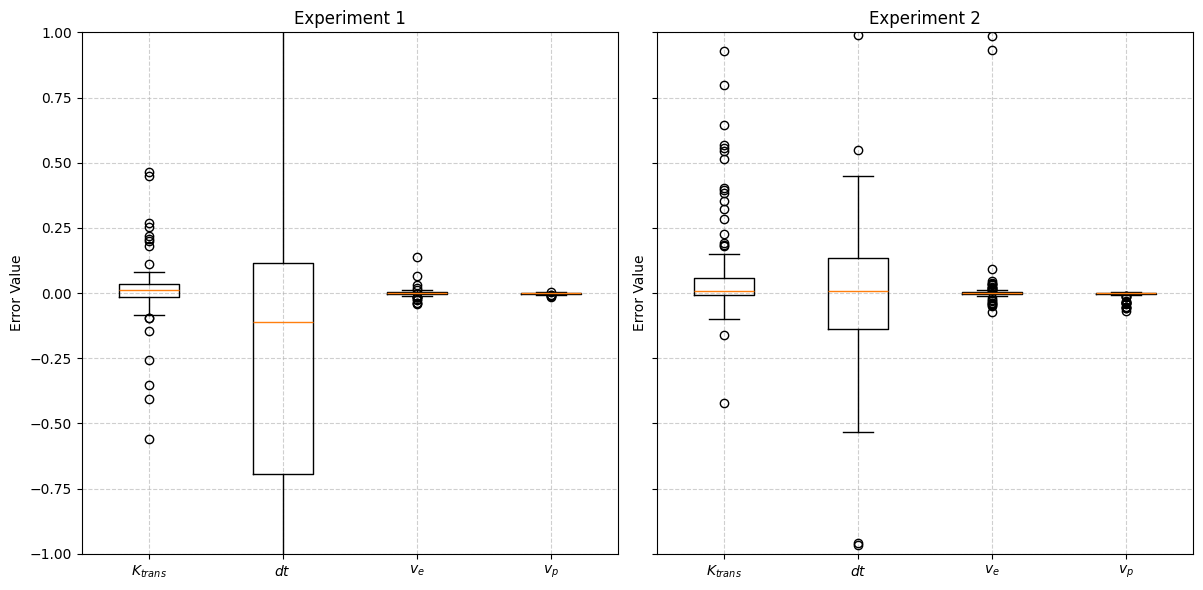

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# Example error_matrix with random values (Shape: 2 experiments, 100 simulations, 4 parameters)

# Define parameter names
param_names = [r'$K_{trans}$', r'$dt$', r'$v_e$', r'$v_p$']  # Adjust names as needed

# Create subplots: One for each experiment
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

for i, ax in enumerate(axes):
    ax.boxplot(error_matrix[i], labels=param_names)
    ax.set_title(f'Experiment {i+1}')
    ax.set_ylabel('Error Value')
    ax.grid(True, linestyle='--', alpha=0.6)

# Adjust layout and show plot
plt.tight_layout()
ax.set_ylim(-1, 1)  # Change 0 and 0.5 to your desired range

plt.show()


Now we make a large dictionary

In [4]:
# Example usage:
alpha = 0.8
sets=1-np.linspace(0, 1, 30)**alpha
Kep_range = sets*1
alpha = 0.7
sets=1-np.linspace(0, 1, 30)**alpha
ve_range = sets*0.3
vp_range = sets*0.1
dt_range = np.linspace(0, 10, 15)

dictionary = generate_dictionary(time_points, AIF, Kep_range, ve_range, vp_range,dt_range)

def compute_Ct(Kep, ve, vp, dt):
    Ct = Cosine8AIF_ExtKety(time_points, AIF, Kep, dt / 60, ve, vp)
    return (Kep, dt, ve, vp), Ct

# Define parameter combinations
param_combinations = list(product(Kep_range, ve_range))
index = faiss.IndexFlatL2(len(time_points))  # L2 (Euclidean) norm matching
pars = []
# Use joblib to parallelize computations
for vp in vp_range:
    for dt in dt_range:
        results = Parallel(n_jobs=6,backend="loky",batch_size="auto")(delayed(compute_Ct)(Kep, ve, vp, dt) for Kep, ve in param_combinations)
        param_array, Ct_array = zip(*results)
        del results
        index.add(np.array(Ct_array))  # Add dictionary to index
        pars.extend(np.array(param_array))  # Store parameters
        del Ct_array, param_array

In [5]:
def dictionary_fais_precal(Ct, dictionary,pars):

    # Search for nearest dictionary entries for all measured signals
    D, I = dictionary.search(Ct.astype(np.float32), 1)  # Find 1 nearest neighbor

    # I contains indices of best matches, D contains distances
    best_match_indices = I.flatten()
    pars=np.array(pars)
    param_matrix = pars[best_match_indices]  # Shape: (num_voxels, num_params)
    return param_matrix


def dictionary_fais_fit(Ct, dictionary,pars):

    # Search for nearest dictionary entries for all measured signals

    param_matrix = dictionary_fais_precal(Ct, dictionary,pars)

    def fitfun(time_points, AIF, Ct, X0):
        return fit_tofts_model(Ct, time_points, AIF, model='Cosine8',X0=X0,bounds=((0.0, 0, 0.0, 0.0), (5.0, 2, 1.0, 1.0)))
    param_matrix[:,1]=param_matrix[:,1]/60
    results = Parallel(n_jobs=6, backend="loky", batch_size="auto")(
        delayed(fitfun)(time_points, AIF, Ct_voxel, X0) for Ct_voxel, X0 in zip(Ct, param_matrix))

    return np.transpose(np.array(results))


In [6]:
sims=1000
vp_min=0.001
vp_max=0.09
ve_min=0.001
ve_max=0.28
kep_min=0.1
kep_max=1
Tonset_min=0.5
Tonset_max=9.5
rg = np.random.RandomState(42)
test = rg.uniform(0, 1, (sims, 1))
vp = vp_min+ (test * (vp_max- vp_min))
test = rg.uniform(0, 1, (sims, 1))
ve = ve_min + (test * (ve_max - ve_min))
test = rg.uniform(0, 1, (sims, 1))
Kep = kep_min + (test * (kep_max - kep_min))
dt = rg.uniform(Tonset_min, Tonset_max, (sims, 1))
Ct = np.zeros((sims, len(time_points)))
error_matrix = np.zeros((3, len(Kep), 4))  # [2 models, num_samples, 3 parameters]
Ctorig=np.zeros((len(time_points),len(Kep)))
for aa in range(len(Kep)):
    Ctorig[:,aa] = Cosine8AIF_ExtKety(time_points, AIF, Kep[aa], dt[aa]/60, ve[aa], vp[aa])

Ct = Ctorig + rg.normal(0, noise, np.shape(Ctorig))

best_params_dict = dictionary_fais_precal(np.transpose(Ct), index,pars)
best_params_dict_tweak = dictionary_fais_fit(np.transpose(Ct), index,pars)
paramsf = fit_tofts_model(np.transpose(Ct), time_points, AIF, model='Cosine8',X0=(0.6, 0, 0.03, 0.0025))

fitting 1000 voxels


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:   11.8s
[Parallel(n_jobs=4)]: Done  88 tasks      | elapsed:   13.4s
[Parallel(n_jobs=4)]: Done 268 tasks      | elapsed:   17.1s
[Parallel(n_jobs=4)]: Done 520 tasks      | elapsed:   22.5s
[Parallel(n_jobs=4)]: Done 880 tasks      | elapsed:   29.0s
[Parallel(n_jobs=4)]: Done 1000 out of 1000 | elapsed:   31.7s finished


Average Fit Errors (dict): Kep=0.3937005603927802, dt=886.2101902048994, ve=0.04192812418036694, vp=0.021417082247950234
Average Fit Errors (paramsf): Kep=0.030789034221247236, dt=0.13809321531150331, ve=0.0031349623983647212, vp=0.001640224199882771
Average Fit Errors (dict+fit): Kep=0.02943360830684516, dt=0.12558844464197927, ve=0.0031080215104494074, vp=0.0014903687038017466

In [9]:
fitted_params0 = np.array([best_params_dict[:,0], best_params_dict[:,1] , best_params_dict[:,2],best_params_dict[:,3]])
fitted_params1 = np.array([paramsf[0], paramsf[1] * 60, paramsf[2],paramsf[3]])  #
fitted_params2 = np.array([best_params_dict_tweak[0], best_params_dict_tweak[1] * 60, best_params_dict_tweak[2],best_params_dict_tweak[3]])  #
      # Convert dt from minutes to seconds
#fitted_params2 = np.array([params_zoom[:,0], params_zoom[:,1] * 60, params_zoom[:,2],params_zoom[:,3]])  #
      # Convert dt from minutes to seconds

true_params = np.squeeze(np.array([Kep, dt, ve, vp]))  # Ground-truth values (including dt)
    # Ground-truth values

error_matrix[0, :, :] = np.transpose(fitted_params0 - true_params)  # Error for params_zoom
error_matrix[1, :, :] =np.transpose(fitted_params1 - true_params) # Error for
error_matrix[2, :, :] = np.transpose(fitted_params2 - true_params)  # Error for params_zoom
# Compute average errors across all samples
average_errors = np.median(np.abs(error_matrix), axis=1)  # Shape: (2,4) → (paramsf errors, params_zoom errors)

# Print average fit errors
print("Average Fit Errors (dict): Kep={}, dt={}, ve={}, vp={}".format(*average_errors[0]))
print("Average Fit Errors (fit): Kep={}, dt={}, ve={}, vp={}".format(*average_errors[1]))
print("Average Fit Errors (dict then fit): Kep={}, dt={}, ve={}, vp={}".format(*average_errors[2]))

Average Fit Errors (dict): Kep=0.036687994269471225, dt=0.2526273330590454, ve=0.004190786321233708, vp=0.0020741820621961345
Average Fit Errors (fit): Kep=0.0442888507386484, dt=0.24574328772461596, ve=0.0036917066003872567, vp=0.0016967681595546763
Average Fit Errors (dict then fit): Kep=0.025080770516560658, dt=0.1164027486688346, ve=0.002650095458250356, vp=0.0010950606521679535
